In [579]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
import control as ctl

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [580]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'test': 2}

In [581]:
TEST_NUM = OPTIONS['test']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test2'

In [582]:
TARGET_VAR  = 'pitch'
LIMITS      = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [30, 100], 'static': [500, 900]}
[500, 900]
[30, 100]


# IMPORTANDO DADOS

In [583]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df

,wx,az,tmp,ay,e,ax,roll,yaw,pitch,time,wy,wz
0,14428,986502,54.7,154923,0.0,23150,-1296,7689,8906,7.152557e-07,8487,-27799
1,13998,988968,54.7,153556,0.0,24269,-1299,7687,8905,3.056693e-02,15654,5060
2,31456,987232,55.0,160225,0.0,22524,-1297,7679,8891,1.198497e-01,-16705,3203
3,55781,940782,55.0,148822,0.0,45012,-1312,7643,8813,2.170892e-01,41269,98387
4,-25725,988542,55.0,158845,0.0,27997,-1232,7659,8727,3.150485e-01,-47173,-1659
...,...,...,...,...,...,...,...,...,...,...,...,...
10067,-9559,986079,62.3,157219,0.0,23675,-1280,356441,9065,1.006646e+03,8303,22358
10068,20677,987953,62.4,155931,0.0,26458,-1278,356442,9065,1.006742e+03,-69602,-12130
10069,-42999,983021,62.4,153590,0.0,25540,-1275,356441,9064,1.006839e+03,-1814,3588
10070,18330,988506,62.2,159819,0.0,22057,-1277,356441,9066,1.006945e+03,-16016,4081


- Convertendo pra radianos

In [584]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,wx,az,tmp,ay,e,ax,roll,yaw,pitch,time,wy,wz
0,0.14428,9.674280,54.7,1.519276,0.0,0.227024,-1.296,7.689,8.906,7.152557e-07,0.08487,-0.27799
1,0.13998,9.698463,54.7,1.505870,0.0,0.237998,-1.299,7.687,8.905,3.056693e-02,0.15654,0.05060
2,0.31456,9.681439,55.0,1.571270,0.0,0.220885,-1.297,7.679,8.891,1.198497e-01,-0.16705,0.03203
3,0.55781,9.225920,55.0,1.459445,0.0,0.441417,-1.312,7.643,8.813,2.170892e-01,0.41269,0.98387
4,-0.25725,9.694285,55.0,1.557737,0.0,0.274557,-1.232,7.659,8.727,3.150485e-01,-0.47173,-0.01659


- Formatando as colunas pra ficar igual a de referência

In [585]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,wx,az,tmp,ay,e,ax,roll,yaw,pitch,time,wy,wz
0,0.14428,1.519276,54.7,9.674280,0.0,0.227024,8.906,7.689,1.296,7.152557e-07,0.27799,0.08487
1,0.13998,1.505870,54.7,9.698463,0.0,0.237998,8.905,7.687,1.299,3.056693e-02,-0.05060,0.15654
2,0.31456,1.571270,55.0,9.681439,0.0,0.220885,8.891,7.679,1.297,1.198497e-01,-0.03203,-0.16705
3,0.55781,1.459445,55.0,9.225920,0.0,0.441417,8.813,7.643,1.312,2.170892e-01,-0.98387,0.41269
4,-0.25725,1.557737,55.0,9.694285,0.0,0.274557,8.727,7.659,1.232,3.150485e-01,0.01659,-0.47173


In [586]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,wx,az,tmp,ay,e,ax,roll,yaw,pitch,time,wy,wz


# VISUALIZAÇÃO DE VARIÁVEIS

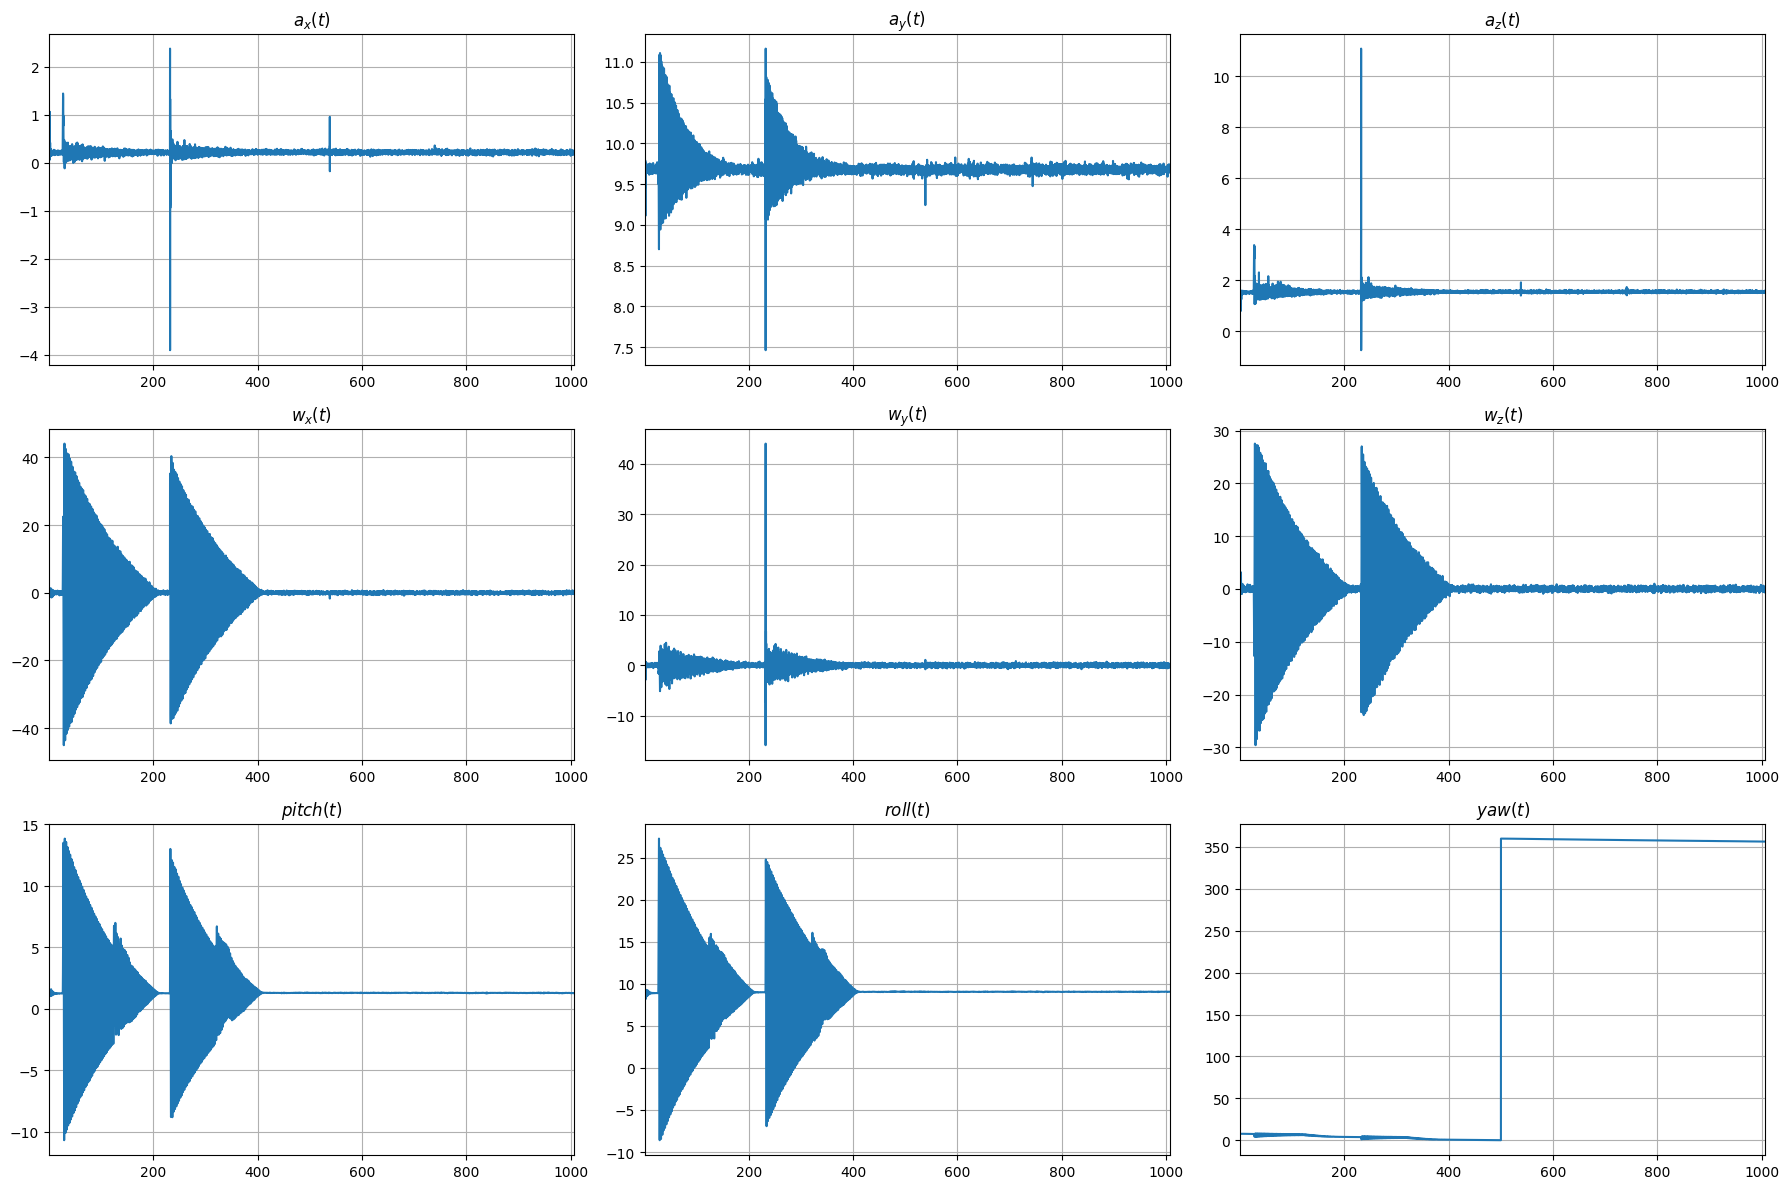

In [587]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

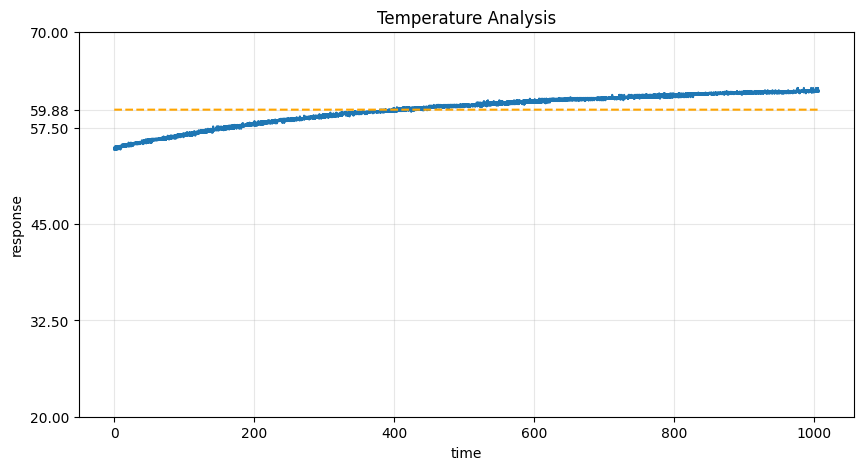

In [588]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

# AMOSTRAGEM

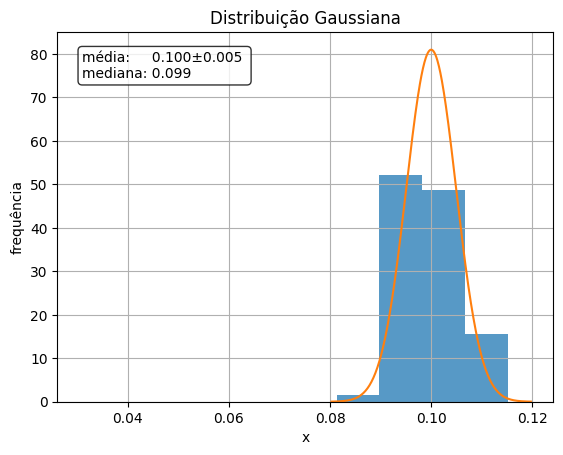

,time,wx,az,tmp,ay,e,ax,roll,yaw,pitch,wy,wz
0,0.0,0.14428,1.519276,54.7,9.674280,0.0,0.227024,8.906,7.689,1.296,0.27799,0.08487
1,0.1,0.13998,1.505870,54.7,9.698463,0.0,0.237998,8.905,7.687,1.299,-0.05060,0.15654
2,0.2,0.31456,1.571270,55.0,9.681439,0.0,0.220885,8.891,7.679,1.297,-0.03203,-0.16705
3,0.3,0.55781,1.459445,55.0,9.225920,0.0,0.441417,8.813,7.643,1.312,-0.98387,0.41269
4,0.4,-0.25725,1.557737,55.0,9.694285,0.0,0.274557,8.727,7.659,1.232,0.01659,-0.47173
...,...,...,...,...,...,...,...,...,...,...,...,...
10067,1006.7,-0.09559,1.541792,62.3,9.670132,0.0,0.232172,9.065,356.441,1.280,-0.22358,0.08303
10068,1006.8,0.20677,1.529161,62.4,9.688509,0.0,0.259464,9.065,356.442,1.278,0.12130,-0.69602
10069,1006.9,-0.42999,1.506203,62.4,9.640143,0.0,0.250462,9.064,356.441,1.275,-0.03588,-0.01814
10070,1007.0,0.18330,1.567289,62.2,9.693932,0.0,0.216305,9.066,356.441,1.277,-0.04081,-0.16016


In [589]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# FILTRAGEM

In [590]:
class FrequencyAnalyzer:
    def __init__(self, xData, yData):
        self.xData = np.asarray(xData)
        self.yData = np.asarray(yData)
        
        self.dt = np.mean(np.diff(self.xData))
        self.nSamples = len(self.yData)
        
        self.yFreq = None
        self.yMag  = None

    def update(self):
        fftResult  = np.fft.fft(self.yData)
        freqs      = np.fft.fftfreq(self.nSamples, self.dt)
        self.yFreq = np.fft.fftshift(freqs)
        self.yMag  = np.fft.fftshift(np.abs(fftResult)) / self.nSamples

    def plot(self, xLim=None, yLim=None, Fc=None):
        self.update()

        plt.plot(self.yFreq, self.yMag, label='blue', color='red', alpha=0.5)

        if Fc is not None:
            yMagRestricted = self.yMag.copy()
            allowed = (np.abs(self.yFreq) <= Fc)
            yMagRestricted[~allowed] = 0
            plt.plot(self.yFreq, yMagRestricted, label=f'Fc={Fc}', color='blue')
        
        plt.xlabel('frequency')
        plt.ylabel('amplitude')
        plt.grid(alpha=0.3)
        
        if xLim: plt.xlim(xLim)
        if yLim: plt.ylim(yLim)
        plt.legend()


class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc
        
        Wc = (2 * np.pi * Fc) 
        s  = ctl.TransferFunction.s
        
        H   = Wc / (s + Wc)
        H_z = ctl.c2d(H, dt, method='tustin')
        
        self.num, self.den = self.getFraction(H_z)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))

    def getFraction(self, G_z):
        num, den = ctl.tfdata(G_z)
        num = np.squeeze(num)
        den = np.squeeze(den)

        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        out = 0.0
        for i in range(len(self.num)):
            out += self.Xn[i] * self.num[i]
        
        for i in range(1, len(self.den)):
            out -= self.Yn[i] * self.den[i]

        return out

    def update(self, inputValue):
        for n in range(len(self.num)-1, 0, -1):
            self.Xn[n] = self.Xn[n-1]

        for n in range(len(self.den)-1, 0, -1):
            self.Yn[n] = self.Yn[n-1]
        
        self.Xn[0] = inputValue
        self.Yn[0] = self.compute()
        return self.Yn[0] if self.Fc > 0 else inputValue

    def apply(self, yData):
        yData = np.array(yData)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))
        for i in range(100): self.update(yData[0])
        return np.array([self.update(val) for val in yData])

    def test(self, df, var, xLim, yLim, limits=(0, 100)):
        plt.figure(figsize=(17, 5))
        plt.subplot(1, 2, 1)
        print('testing', var)
        FrequencyAnalyzer(df.time, df[var]).plot(xLim, yLim, Fc=Fc)

        plt.subplot(1, 2, 2)
        target = df.loc[(df.time >= limits[0]) & (df.time <= limits[1])]
        plt.plot(target.time, target[var], label='values')
        plt.plot(target.time, self.apply(target[var]), label=f'Fc={Fc}', linewidth=2)
        plt.grid(alpha=0.3); plt.legend()
        plt.xlabel('time'); plt.ylabel('values')
        plt.show()
        df[var] = self.apply(df[var])
        return df.copy()


APPLY_FILTERS = False

if APPLY_FILTERS:
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ax', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ay', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'az', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))

    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wx', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wy', xLim=(-5, 5), yLim=(0, 0.1),  limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wz', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [591]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,wx,az,tmp,ay,e,ax,roll,yaw,pitch,wy,wz,static
0,0.0,32.10761,1.472733,55.4,10.080864,0.0,-0.115061,20.617,5.425,9.819,-2.15687,-20.81148,False
1,0.1,24.00785,1.332871,55.5,9.576998,0.0,-0.033117,23.347,4.695,11.864,-1.23790,-14.74208,False
2,0.2,14.67136,1.309806,55.4,9.160235,0.0,0.034147,25.234,4.135,13.237,-0.37318,-8.57073,False
3,0.3,4.75546,1.220251,55.5,8.941507,0.0,0.076600,26.179,3.886,13.824,0.07954,-1.27825,False
4,0.4,-6.16720,1.223262,55.5,9.048145,0.0,0.131252,26.114,3.952,13.599,0.03520,5.46247,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4696,469.5,-0.22118,1.563857,62.3,9.621706,0.0,0.223847,9.052,357.174,1.283,-0.30304,-0.22107,True
4697,469.6,-0.25937,1.544302,62.1,9.652754,0.0,0.199948,9.048,357.172,1.280,-0.10952,-0.08764,True
4698,469.7,0.14069,1.544920,62.0,9.662796,0.0,0.231329,9.046,357.171,1.279,-0.05265,0.01269,True
4699,469.8,-0.00101,1.532122,62.1,9.721332,0.0,0.222238,9.048,357.171,1.275,0.05136,0.16285,True


# FILTRANDO POR VARIAVEL

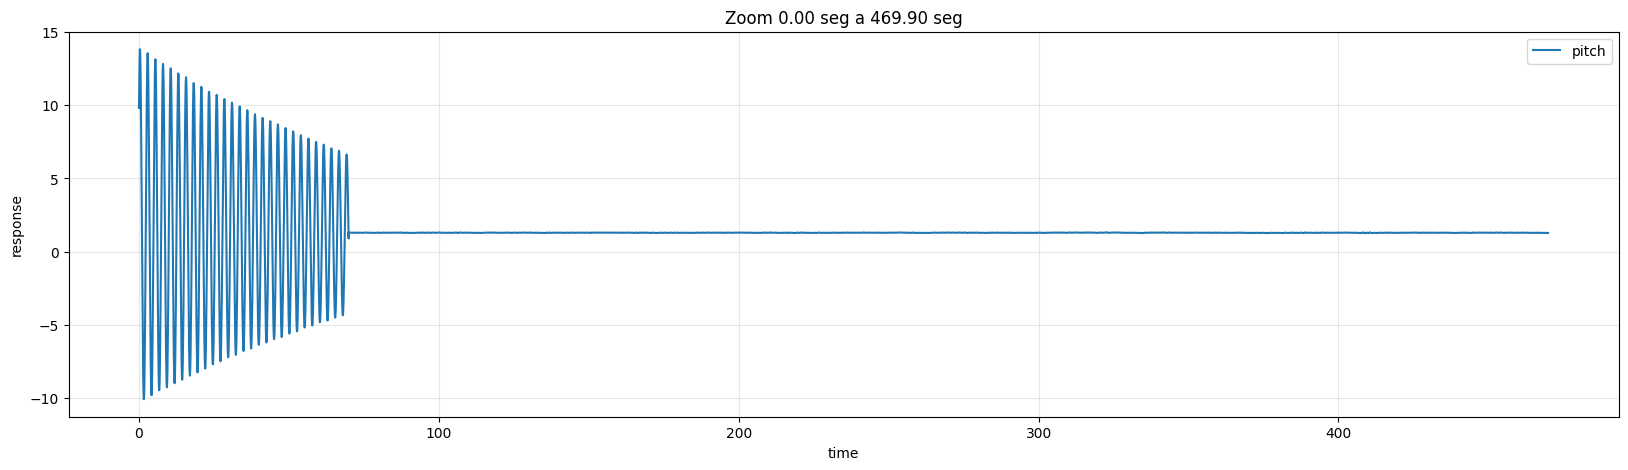

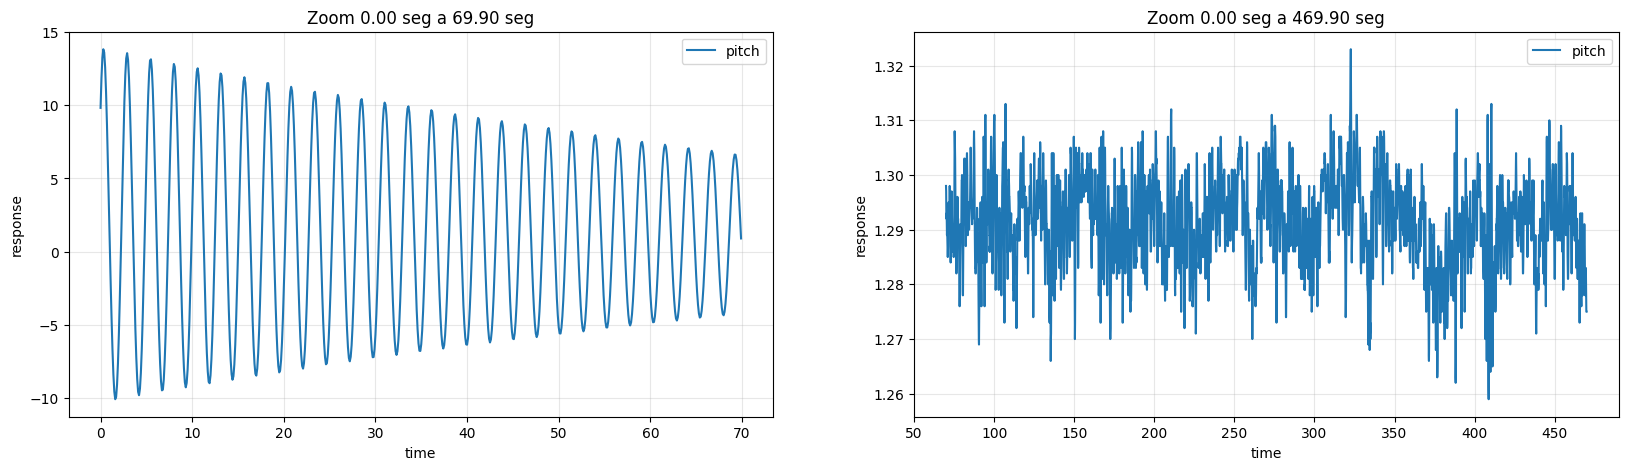

In [592]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [593]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,target_wx,target_az,target_tmp,target_ay,target_e,target_ax,target_roll,target_yaw,target_pitch,target_wy,target_wz,static
0,0.0,32.10761,1.472733,55.4,10.080864,0.0,-0.115061,20.617,5.425,9.819,-2.15687,-20.81148,False
1,0.1,24.00785,1.332871,55.5,9.576998,0.0,-0.033117,23.347,4.695,11.864,-1.23790,-14.74208,False
2,0.2,14.67136,1.309806,55.4,9.160235,0.0,0.034147,25.234,4.135,13.237,-0.37318,-8.57073,False
3,0.3,4.75546,1.220251,55.5,8.941507,0.0,0.076600,26.179,3.886,13.824,0.07954,-1.27825,False
4,0.4,-6.16720,1.223262,55.5,9.048145,0.0,0.131252,26.114,3.952,13.599,0.03520,5.46247,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4696,469.5,-0.22118,1.563857,62.3,9.621706,0.0,0.223847,9.052,357.174,1.283,-0.30304,-0.22107,True
4697,469.6,-0.25937,1.544302,62.1,9.652754,0.0,0.199948,9.048,357.172,1.280,-0.10952,-0.08764,True
4698,469.7,0.14069,1.544920,62.0,9.662796,0.0,0.231329,9.046,357.171,1.279,-0.05265,0.01269,True
4699,469.8,-0.00101,1.532122,62.1,9.721332,0.0,0.222238,9.048,357.171,1.275,0.05136,0.16285,True


In [594]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)